Исходя из проблемы и данных входных данных возникает диссонанс с тем, что несмотря на ухудшение конверсии, люди начали активнее скачивать приложение и при этом люди, кто устанавливал приложение 7 назад по прежнему заходят в программу и совершают какие-то действия. Это сразу же наталкивает на мысль, что следует внимательнее приглядеться к самой конверсии, может быть она некорректно высчитана, так как довольно странно, что ее значение падает, а при этом значение того же удержания остается на прежнем уровне. 

Сейчас у нас конверсия имеет вид: $$\text{Конверсия} = \frac{\text{Первые поездки}}{\text{Первые входы}}$$

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('data.xlsx') 
df.head(10)

,Дата,Неделя,Установки,Регистрации,Открыли поиск,Просмотрели авто,Забронировали,Первая поездка
0,06.01.2025,Неделя 1,206,130,91,70,57,51
1,07.01.2025,Неделя 1,216,138,98,73,55,48
2,08.01.2025,Неделя 1,181,117,86,69,52,46
3,09.01.2025,Неделя 1,212,134,101,83,64,54
4,10.01.2025,Неделя 1,218,143,97,73,60,53
5,11.01.2025,Неделя 1,212,146,106,90,70,62
6,12.01.2025,Неделя 1,213,145,110,89,72,60
7,13.01.2025,Неделя 2,189,123,83,64,48,41
8,14.01.2025,Неделя 2,205,135,95,73,56,52
9,15.01.2025,Неделя 2,206,140,96,79,59,51


In [3]:
df.isna().any()

Дата                False
Неделя              False
Установки           False
Регистрации         False
Открыли поиск       False
Просмотрели авто    False
Забронировали       False
Первая поездка      False
dtype: bool

In [4]:
df['Конверсия'] = df['Первая поездка'] / df['Установки']

In [5]:
numeric = df.select_dtypes(include = ['number']).columns

In [6]:
week = df.groupby('Неделя')[numeric].sum().reset_index().drop(index = 0)

In [7]:
week['Конверсия'] = week['Первая поездка'] / week['Установки']

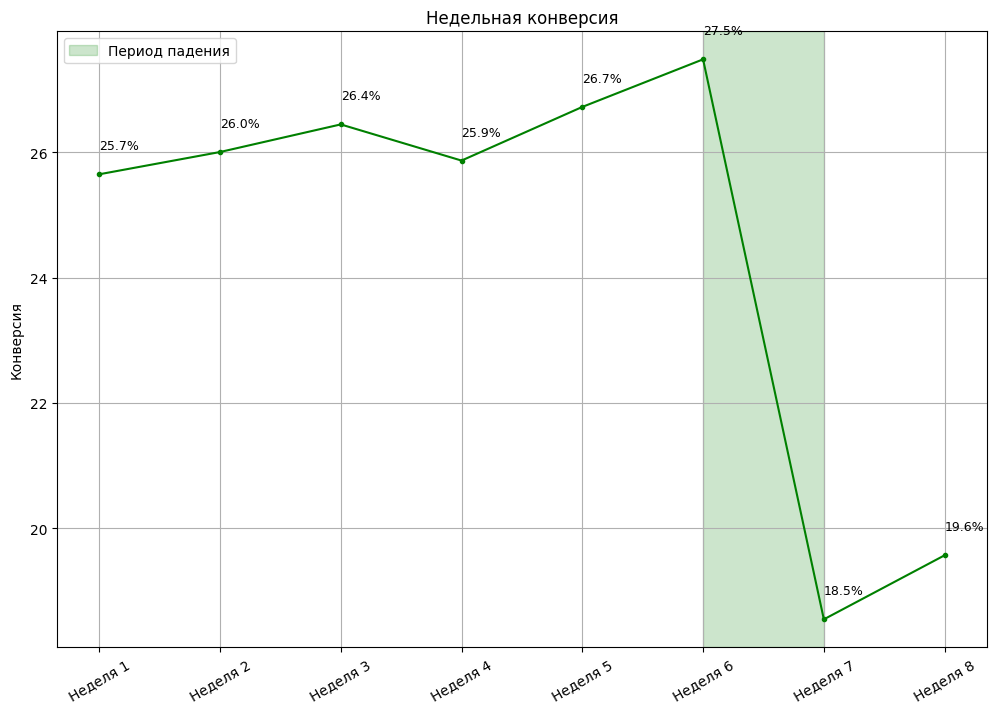

In [8]:
plt.figure(figsize = (12, 8))
plt.plot(week['Неделя'], week['Конверсия'] * 100, marker = '.', color = 'green')
plt.title('Недельная конверсия')
plt.axvspan('Неделя 6', 'Неделя 7', alpha = 0.2, color = 'green', label = 'Период падения')
plt.xticks(rotation = 30)
plt.ylabel('Конверсия')
plt.grid(True)

for i, row in week.iterrows():
    plt.text(row['Неделя'], row['Конверсия'] * 100 + 0.4, f'{row['Конверсия'] * 100:.1f}%', ha = 'left', fontsize = 9) 
plt.legend()
plt.savefig('conversion.png', dpi = 800)
plt.show()

Взглянем на отдельные конверсии других величин, чтобы понять, что конкретно обвалило 6-7 неделю

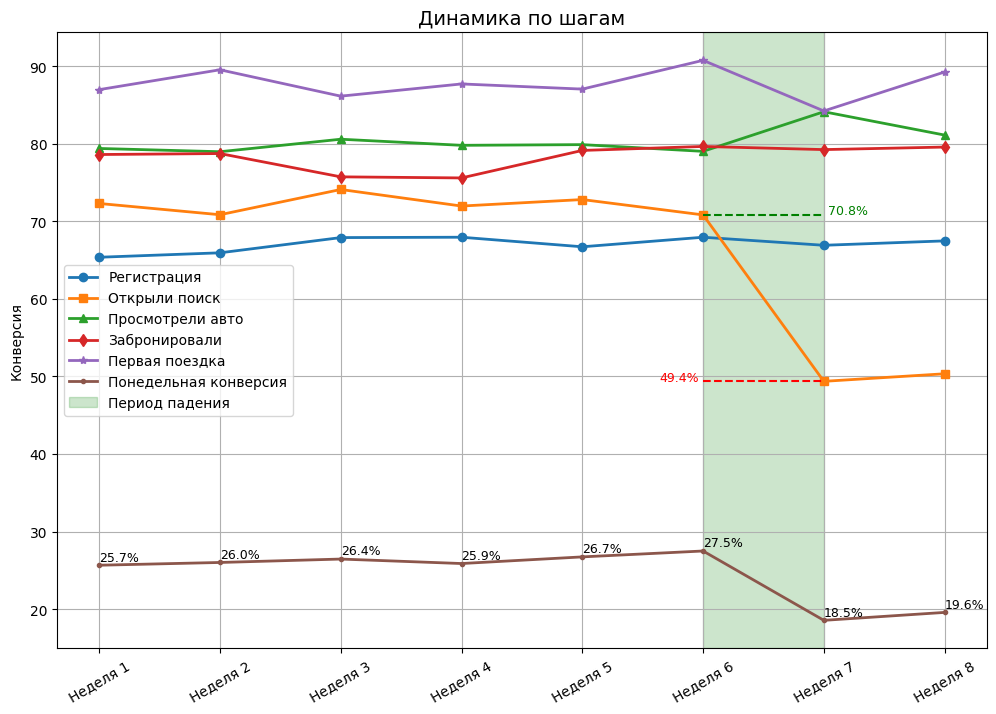

In [9]:
week['Конверсия регистраций'] = week['Регистрации'] / week['Установки']
week['Конверсия искавших'] = week['Открыли поиск'] / week['Регистрации']
week['Конверсия просмотров'] = week['Просмотрели авто'] / week['Открыли поиск']
week['Конверсия брони'] = week['Забронировали'] / week['Просмотрели авто']
week['Конверсия поездки'] = week['Первая поездка'] / week['Забронировали']

plt.figure(figsize = (12, 8))
plt.plot(week['Неделя'], week['Конверсия регистраций'] * 100, marker = 'o', label = 'Регистрация', linewidth = 2)
plt.plot(week['Неделя'], week['Конверсия искавших'] * 100, marker = 's', label = 'Открыли поиск', linewidth = 2)
plt.plot(week['Неделя'], week['Конверсия просмотров'] * 100, marker = '^', label = 'Просмотрели авто', linewidth = 2)
plt.plot(week['Неделя'], week['Конверсия брони'] * 100, marker = 'd', label = 'Забронировали', linewidth = 2)
plt.plot(week['Неделя'], week['Конверсия поездки'] * 100, marker = '*', label = 'Первая поездка', linewidth = 2)
plt.plot(week['Неделя'], week['Конверсия'] * 100, marker = '.', label = 'Понедельная конверсия', linewidth = 2)
for i, row in week.iterrows():
    plt.text(row['Неделя'], row['Конверсия'] * 100 + 0.6, f'{row['Конверсия'] * 100:.1f}%', ha = 'left', fontsize = 9) 
plt.axvspan('Неделя 6', 'Неделя 7', alpha = 0.2, color = 'green', label = 'Период падения')
y1 = week.loc[week['Неделя'] == 'Неделя 6', 'Конверсия искавших'].values[0] * 100
y2 = week.loc[week['Неделя'] == 'Неделя 7', 'Конверсия искавших'].values[0] * 100
plt.hlines(y = y1, xmin = 5, xmax = 6, colors = 'green', linestyles = '--', linewidth = 1.5)
plt.hlines(y = y2, xmin = 5, xmax = 6, colors = 'red', linestyles = '--', linewidth = 1.5)
plt.text(6.2, y1 + 0.1, f'{y1:.1f}%', color = 'green', fontsize = 9, ha = 'center')
plt.text(4.8, y2 + 0.1, f'{y2:.1f}%', color = 'red', fontsize = 9, ha = 'center')
plt.title('Динамика по шагам', fontsize = 14)
plt.ylabel('Конверсия')
plt.xticks(rotation = 30)
plt.legend()
plt.grid(True)
plt.savefig('dynamics.png', dpi = 800)
plt.show()